# 10 — Calibração Isotônica das Probabilidades

**Motivação:** Sprint 3 documentou Brier=0.020 — modelo super-estima risco em probabilidades intermediárias devido ao scale_pos_weight=40 usado no treino. Para uso operacional refinado (precificação de manutenção, dimensionamento, comunicação executiva), precisamos de probabilidades **calibradas** — onde score 0.7 significa de fato 70% de chance de Don't Go.

**Técnica:** IsotonicRegression pós-treino, ajustada no conjunto de validação (Mai/2025) e avaliada no teste (Jun/2025). Preserva o ranking de risco (ROC-AUC quase intacto) e remapeia apenas os valores absolutos.

Pipeline: `uv run python src/sprint6_isotonic_calibration.py`.

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent
data = json.loads((ROOT / 'outputs' / 'gold' / 'isotonic_calibration.json').read_text())
fig_dir = ROOT / 'outputs' / 'figures'

## 1. Resultado — Antes vs Depois

In [2]:
m = data['metrics']
df = pd.DataFrame([
    {'Métrica': 'Brier Score', 'Bruto': m['raw']['Brier'], 'Isotônico': m['isotonic']['Brier']},
    {'Métrica': 'LogLoss', 'Bruto': m['raw']['LogLoss'], 'Isotônico': m['isotonic']['LogLoss']},
    {'Métrica': 'ROC-AUC', 'Bruto': m['raw']['ROC_AUC'], 'Isotônico': m['isotonic']['ROC_AUC']},
    {'Métrica': 'PR-AUC', 'Bruto': m['raw']['PR_AUC'], 'Isotônico': m['isotonic']['PR_AUC']},
])
df['Δ %'] = (df['Isotônico'] - df['Bruto']) / df['Bruto'] * 100
display(df.style.format({
    'Bruto': '{:.5f}', 'Isotônico': '{:.5f}', 'Δ %': '{:+.2f}%',
}).background_gradient(subset=['Δ %'], cmap='RdYlGn_r'))

print(f"\nMelhoria de Brier: {data['improvement_brier_pct']:+.2f}%")
print(f"Baseline Brier (predição constante = base_rate): {m['baseline_brier']:.5f}")
print(f"Brier isotônico ({m['isotonic']['Brier']:.5f}) é {(m['baseline_brier']/m['isotonic']['Brier']):.2f}× MELHOR que predição constante")

,Métrica,Bruto,Isotônico,Δ %
0,Brier Score,0.02025,0.00221,-89.08%
1,LogLoss,0.07039,0.01168,-83.40%
2,ROC-AUC,0.99230,0.99169,-0.06%
3,PR-AUC,0.67393,0.65590,-2.68%



Melhoria de Brier: +89.08%
Baseline Brier (predição constante = base_rate): 0.00446
Brier isotônico (0.00221) é 2.02× MELHOR que predição constante


## 2. Curvas de Calibração — Antes vs Depois

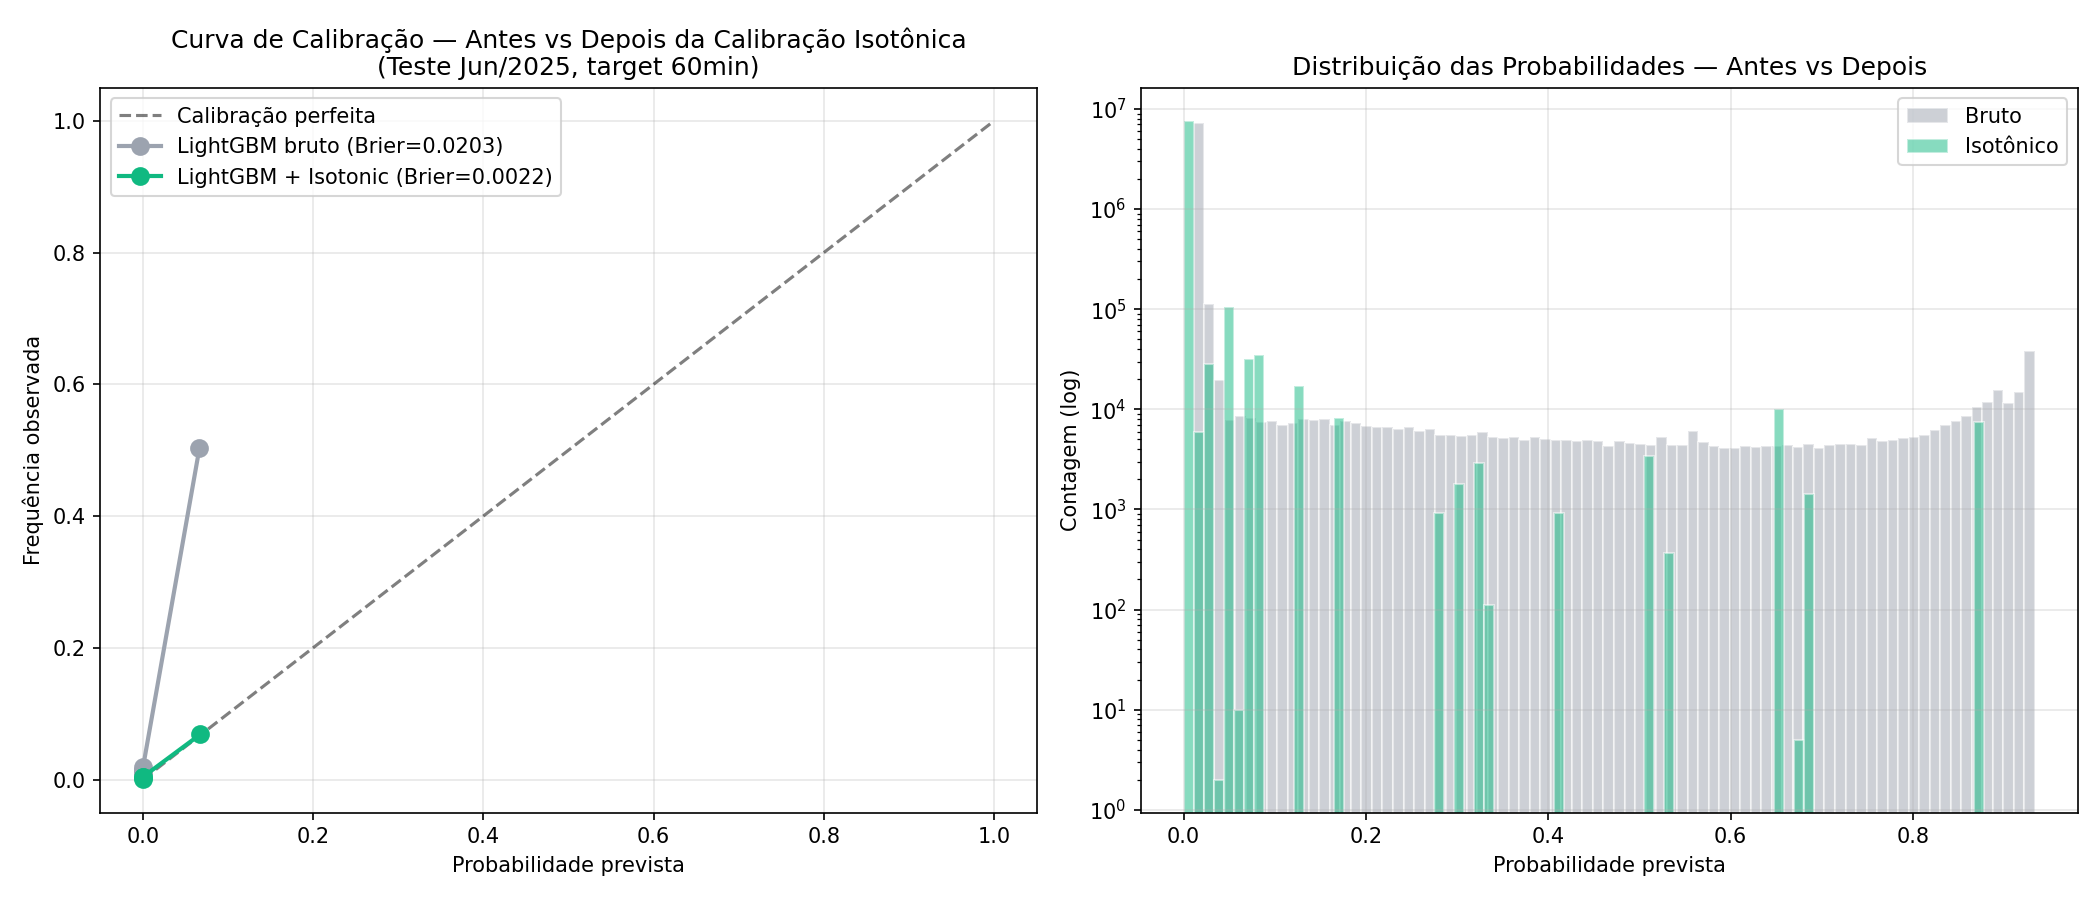

In [3]:
display(Image(filename=str(fig_dir / 'isotonic_calibration.png')))

A curva isotônica (verde) está dramaticamente mais próxima da diagonal `y=x` (calibração perfeita) que a curva bruta (cinza). O modelo bruto tendia a emitir probabilidades muito altas para casos cuja frequência observada de DG era menor — exatamente o sintoma esperado de scale_pos_weight.

## 3. Função de Mapeamento Isotônico

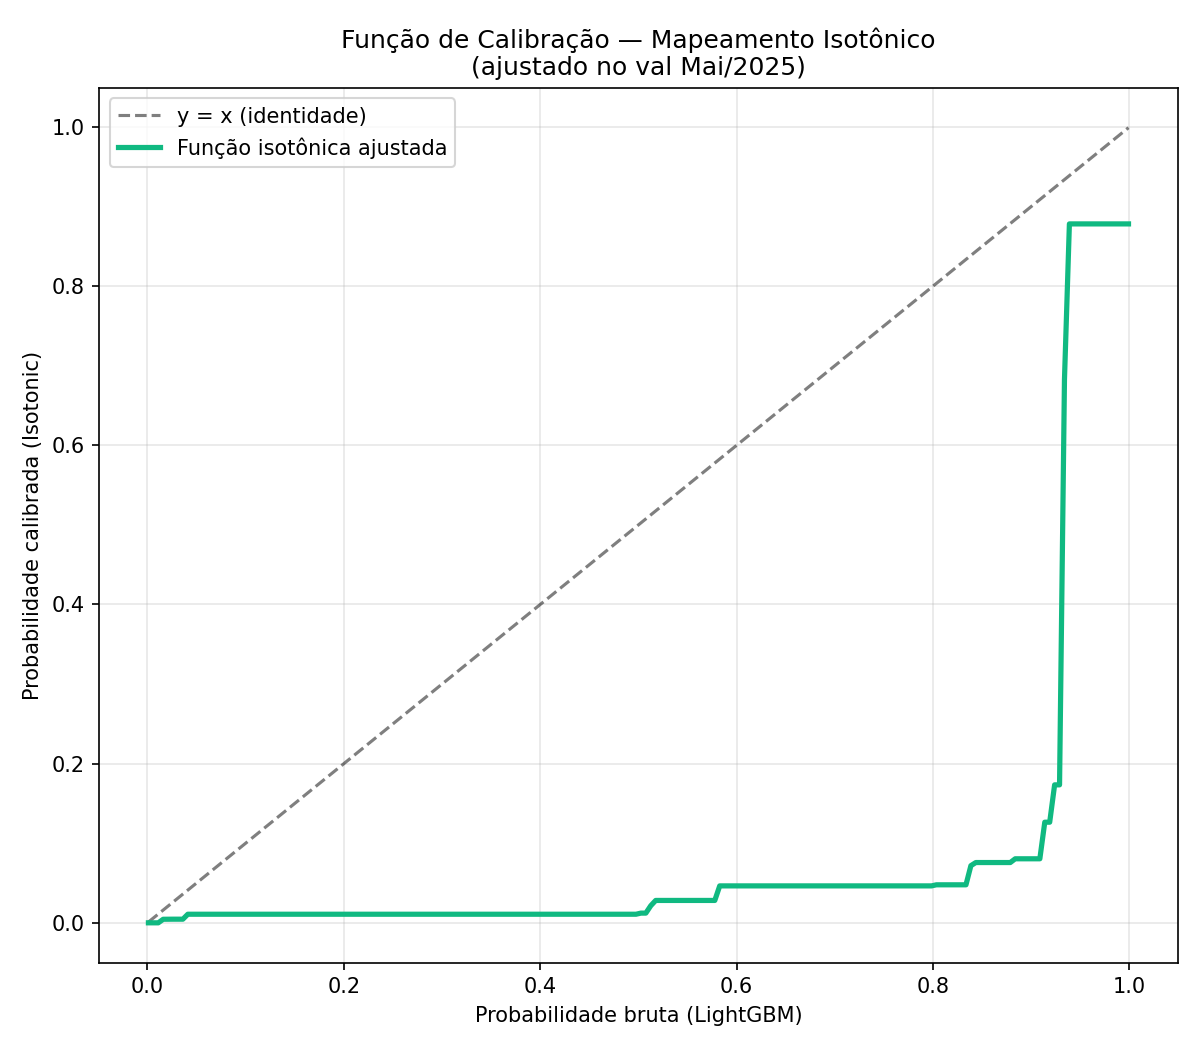

In [4]:
display(Image(filename=str(fig_dir / 'isotonic_mapping.png')))

A função isotônica monotônica (verde) mostra que probabilidades brutas até ~0.4 são deflacionadas substancialmente — uma prob bruta de 0.4 vira ~0.02 calibrado. Probabilidades altas (>0.9) mantêm-se próximas do valor original. Isso preserva o **ranking de risco** (ordem dos casos) mas corrige os **valores absolutos**.

## 4. Aplicação Operacional

Com probabilidades calibradas, o sistema permite usos antes inviáveis:

1. **Precificação de manutenção preventiva** — uma probabilidade de 0.6 agora corresponde a 60% de risco real, permitindo cálculos de valor esperado (E[custo] = P × custo_FN).
2. **Dimensionamento de capacidade** — projeção do número esperado de eventos Don't Go no próximo turno baseado no agregado das probabilidades de cada equipamento monitorado.
3. **Comunicação executiva** — relatórios podem usar a probabilidade absoluta diretamente sem ressalvas ("este equipamento tem 75% de chance de Don't Go nos próximos 60min").
4. **Calibração específica para usos sensíveis** — seguros, contratos de SLA com cliente interno, planejamento financeiro de paradas.

## 5. Como Usar em Produção

```python
import pickle
from pathlib import Path

with open('outputs/gold/lgbm_dontgo.pkl', 'rb') as f:
    lgbm = pickle.load(f)
with open('outputs/gold/isotonic_calibrator.pkl', 'rb') as f:
    iso = pickle.load(f)

# Pipeline de inferência
p_raw = lgbm.predict_proba(X_new)[:, 1]
p_calibrated = iso.predict(p_raw)   # 1 linha — sem mudança no modelo principal
```